In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE


In [2]:
df=pd.read_csv(r"C:\xampp816\htdocs\personal-dev\py-ds\ML\salary\adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [6]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [7]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [8]:
df["workclass"]=df["workclass"].replace("?",np.nan)

In [9]:
df["occupation"]=df["occupation"].replace("?",np.nan)

In [10]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [11]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [12]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country       0
income               0
dtype: int64

In [13]:
df=df.dropna()

In [14]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [15]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(24)

In [17]:
df=df.drop_duplicates()

In [18]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [19]:
df=df.drop(columns=["education","capital.gain","capital.loss"])

In [20]:
df

,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
1,82,Private,132870,9,Widowed,Exec-managerial,Not-in-family,White,Female,18,United-States,<=50K
3,54,Private,140359,4,Divorced,Machine-op-inspct,Unmarried,White,Female,40,United-States,<=50K
4,41,Private,264663,10,Separated,Prof-specialty,Own-child,White,Female,40,United-States,<=50K
5,34,Private,216864,9,Divorced,Other-service,Unmarried,White,Female,45,United-States,<=50K
6,38,Private,150601,6,Separated,Adm-clerical,Unmarried,White,Male,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,10,Never-married,Protective-serv,Not-in-family,White,Male,40,United-States,<=50K
32557,27,Private,257302,12,Married-civ-spouse,Tech-support,Wife,White,Female,38,United-States,<=50K
32558,40,Private,154374,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,>50K
32559,58,Private,151910,9,Widowed,Adm-clerical,Unmarried,White,Female,40,United-States,<=50K


In [21]:
df[df["sex"]=="Male"]["income"].value_counts()

income
<=50K    14252
>50K      6521
Name: count, dtype: int64

In [22]:
df["marital.status"].value_counts()

marital.status
Married-civ-spouse       14333
Never-married             9896
Divorced                  4256
Separated                  959
Widowed                    840
Married-spouse-absent      389
Married-AF-spouse           21
Name: count, dtype: int64

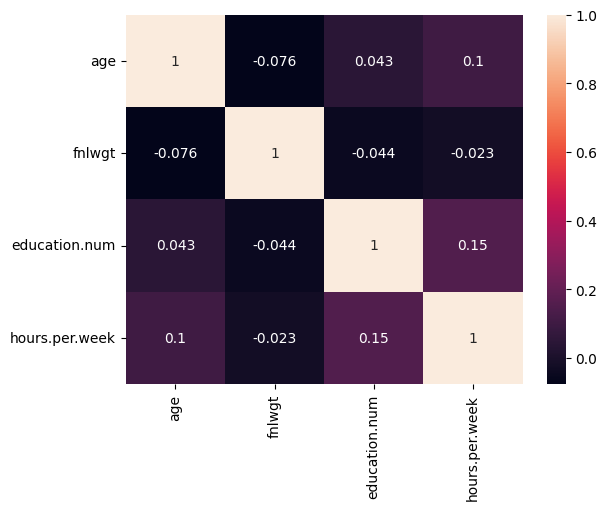

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [24]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
hours.per.week     int64
native.country    object
income            object
dtype: object

### IQR

In [25]:
dict1={}
for i in df:
    if df[i].dtype=="int64" or df[i].dtype=="float":
        q1=df[i].quantile(0.25)
        q3=df[i].quantile(0.75)
        iqr=q3-q1
        min_range=q1-1.5*iqr
        max_range=q3+1.5*iqr
        dict1[i]=(min_range,max_range)

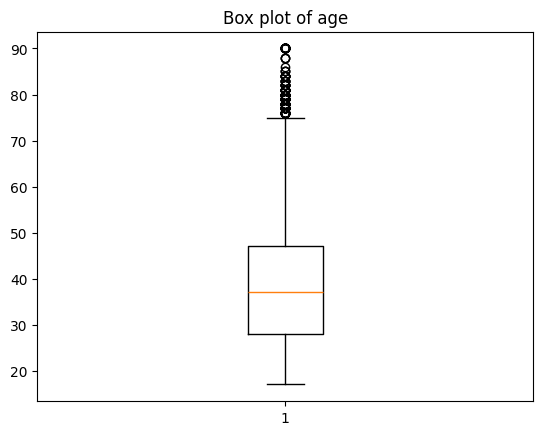

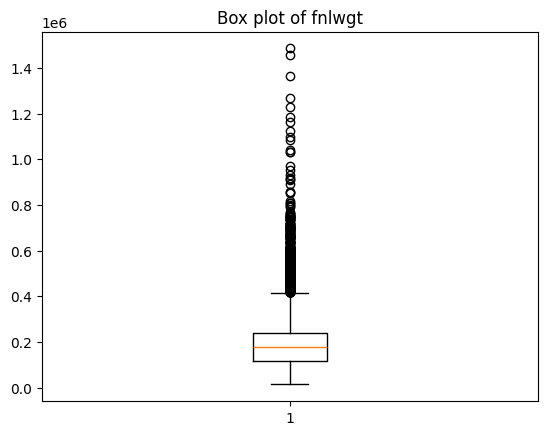

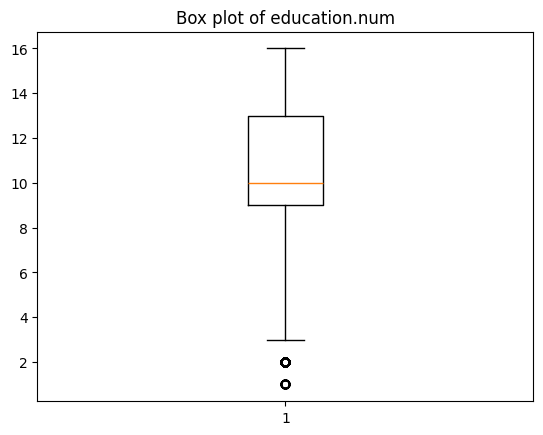

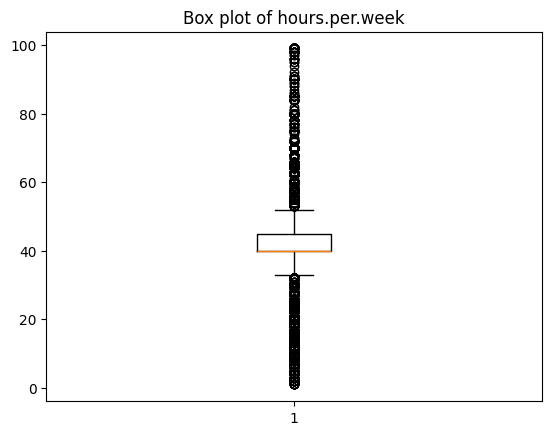

In [26]:
for i in df:
    if df[i].dtype=="int64" or df[i].dtype=="float":
        plt.boxplot(df[i])
        plt.title(f"Box plot of {i}")
        plt.show()

### Encoding

In [27]:
label=[]
for i in df:
    if df[i].nunique()==2 and df[i].dtype=="object":
        label.append(i)


In [28]:
dict1={}
for i in label:
    dict1[i]=LabelEncoder()
    df[i]=dict1[i].fit_transform(df[i])

In [29]:
label

['sex', 'income']

In [30]:
df.reset_index(drop=True,inplace=True)

In [31]:
df_new=df.copy()

In [32]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex                int64
hours.per.week     int64
native.country    object
income             int64
dtype: object

In [33]:
onehot=OneHotEncoder(sparse_output=False,drop="first")
res=onehot.fit_transform(df_new[["marital.status","occupation","relationship","race","native.country","workclass"]])

In [34]:
df_new.drop(columns=["marital.status","occupation","relationship","race","native.country","workclass"],inplace=True)

In [35]:
res=pd.DataFrame(res,columns=onehot.get_feature_names_out())

In [36]:
df=df_new.join(res)

In [37]:
df

,age,fnlwgt,education.num,sex,hours.per.week,income,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,...,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,82,132870,9,0,18,0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,54,140359,4,0,40,0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,41,264663,10,0,40,0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,34,216864,9,0,45,0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,38,150601,6,1,40,0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30689,22,310152,10,1,40,0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
30690,27,257302,12,0,38,0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
30691,40,154374,9,1,40,1,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
30692,58,151910,9,0,40,0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Scaling

In [38]:
x=df.drop(columns=["income"])
y=df["income"]

In [39]:
minmax=MinMaxScaler()
x_scaled=minmax.fit_transform(x)

In [40]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=42)

In [41]:
df["income"].value_counts()

income
0    23046
1     7648
Name: count, dtype: int64

### UnderSampling

In [42]:
under_sampler=RandomUnderSampler()
x_under,y_under=under_sampler.fit_resample(x_scaled,y)

### Smote

In [43]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_over_s,y_over_s=smote.fit_resample(x_scaled,y)

KNeighborsClassifier() 
--------
              precision    recall  f1-score   support

           0       0.95      0.77      0.85      6967
           1       0.55      0.87      0.67      2242

    accuracy                           0.79      9209
   macro avg       0.75      0.82      0.76      9209
weighted avg       0.85      0.79      0.81      9209

79.43316320990336


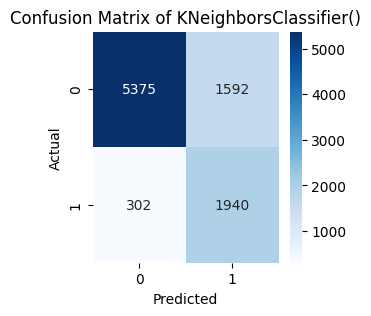

SVC() 
--------
              precision    recall  f1-score   support

           0       0.94      0.75      0.84      6967
           1       0.53      0.85      0.65      2242

    accuracy                           0.78      9209
   macro avg       0.73      0.80      0.74      9209
weighted avg       0.84      0.78      0.79      9209

77.66315560864372


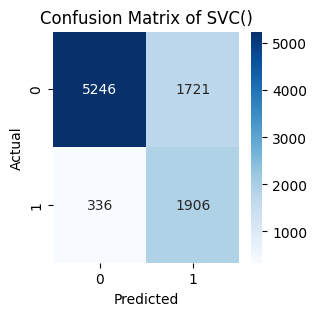

DecisionTreeClassifier() 
--------
              precision    recall  f1-score   support

           0       1.00      0.82      0.90      6967
           1       0.64      1.00      0.78      2242

    accuracy                           0.86      9209
   macro avg       0.82      0.91      0.84      9209
weighted avg       0.91      0.86      0.87      9209

86.48061678792486


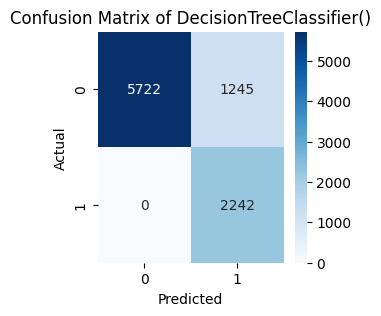

GaussianNB() 
--------
              precision    recall  f1-score   support

           0       0.95      0.43      0.59      6967
           1       0.34      0.94      0.50      2242

    accuracy                           0.55      9209
   macro avg       0.65      0.68      0.55      9209
weighted avg       0.81      0.55      0.57      9209

54.98968400477794


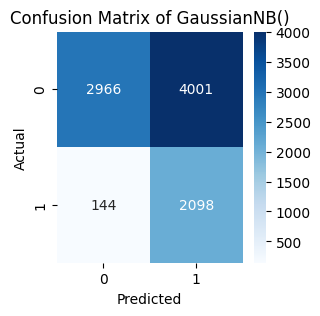

RandomForestClassifier() 
--------
              precision    recall  f1-score   support

           0       1.00      0.86      0.93      6967
           1       0.70      1.00      0.82      2242

    accuracy                           0.90      9209
   macro avg       0.85      0.93      0.87      9209
weighted avg       0.93      0.90      0.90      9209

89.53197958518841


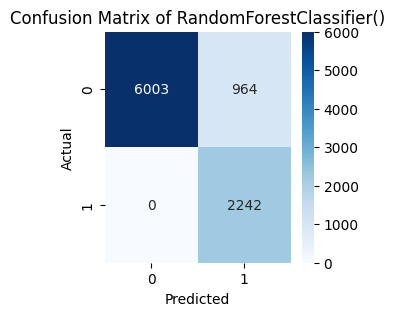

GradientBoostingClassifier() 
--------
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      6967
           1       0.55      0.85      0.67      2242

    accuracy                           0.80      9209
   macro avg       0.75      0.81      0.76      9209
weighted avg       0.85      0.80      0.81      9209

79.60690628732762


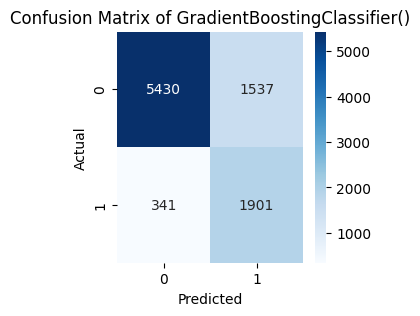

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) 
--------
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      6967
           1       0.59      0.90      0.72      2242

    accuracy                           0.83      9209
   macro av

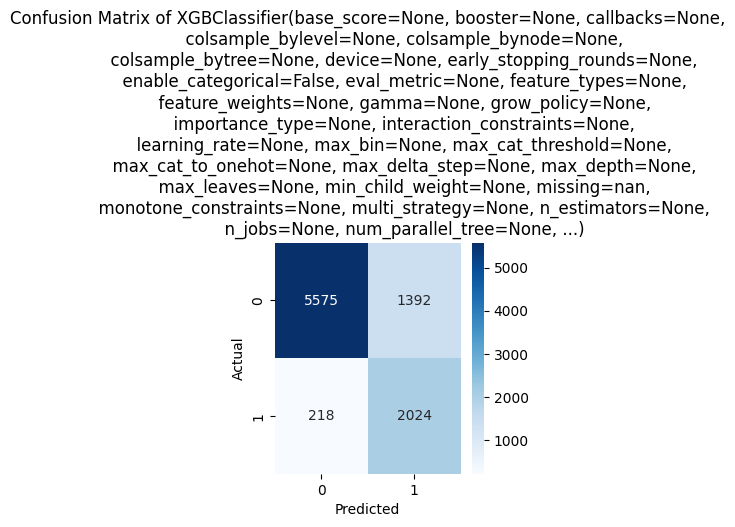

In [44]:
models=[KNeighborsClassifier(),SVC(),DecisionTreeClassifier(),GaussianNB(),RandomForestClassifier(),GradientBoostingClassifier(),XGBClassifier()]
for model in models:
    model.fit(x_under,y_under)
    y_pred=model.predict(x_test)
    print(model,"\n--------")
    print(classification_report(y_test,y_pred))
    print(accuracy_score(y_test,y_pred)*100)
    plt.figure(figsize=(3,3))
    sns.heatmap(confusion_matrix(y_test,y_pred),fmt="d",cmap="Blues",annot=True)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix of {model}")
    plt.show()

In [45]:
cross_val_score(GaussianNB(),x_scaled,y,cv=6).mean()

np.float64(0.5239795811783755)

In [46]:
cross_val_score(DecisionTreeClassifier(),x_scaled,y,cv=6).mean()

np.float64(0.7733434817289391)

In [47]:
cross_val_score(RandomForestClassifier(),x_scaled,y,cv=6).mean()

np.float64(0.8222127642283259)

KNeighborsClassifier() 
--------
              precision    recall  f1-score   support

           0       0.97      0.83      0.89      6967
           1       0.63      0.91      0.75      2242

    accuracy                           0.85      9209
   macro avg       0.80      0.87      0.82      9209
weighted avg       0.88      0.85      0.86      9209

84.81919861005538


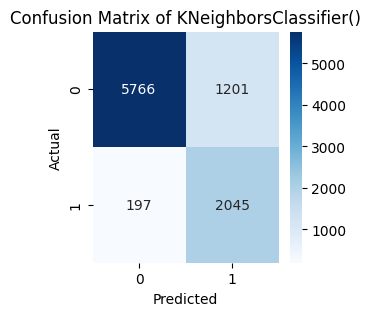

SVC() 
--------
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      6967
           1       0.54      0.85      0.66      2242

    accuracy                           0.79      9209
   macro avg       0.74      0.81      0.75      9209
weighted avg       0.84      0.79      0.80      9209

78.74904984254533


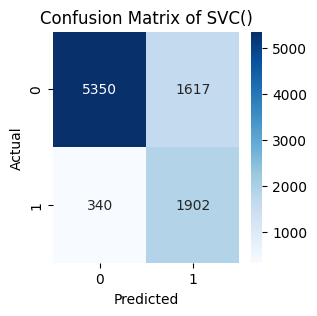

DecisionTreeClassifier() 
--------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6967
           1       1.00      1.00      1.00      2242

    accuracy                           1.00      9209
   macro avg       1.00      1.00      1.00      9209
weighted avg       1.00      1.00      1.00      9209

99.98914105766097


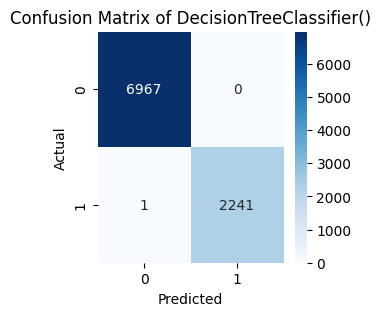

GaussianNB() 
--------
              precision    recall  f1-score   support

           0       0.95      0.37      0.53      6967
           1       0.32      0.94      0.48      2242

    accuracy                           0.51      9209
   macro avg       0.64      0.66      0.51      9209
weighted avg       0.80      0.51      0.52      9209

50.732978607883595


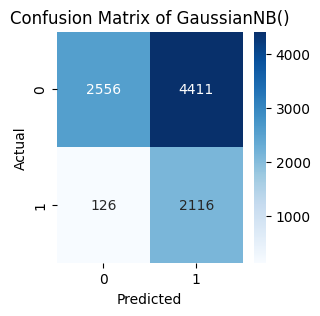

RandomForestClassifier() 
--------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6967
           1       1.00      1.00      1.00      2242

    accuracy                           1.00      9209
   macro avg       1.00      1.00      1.00      9209
weighted avg       1.00      1.00      1.00      9209

99.97828211532197


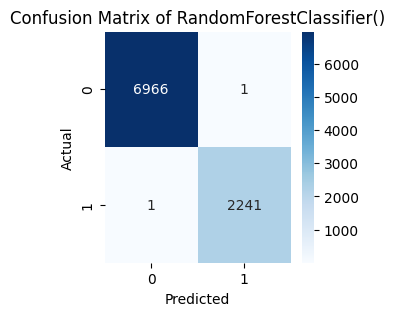

GradientBoostingClassifier() 
--------
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      6967
           1       0.57      0.81      0.67      2242

    accuracy                           0.80      9209
   macro avg       0.75      0.80      0.76      9209
weighted avg       0.84      0.80      0.81      9209

80.29101965468564


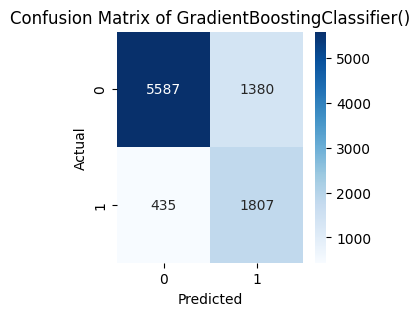

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) 
--------
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      6967
           1       0.68      0.77      0.72      2242

    accuracy                           0.86      9209
   macro av

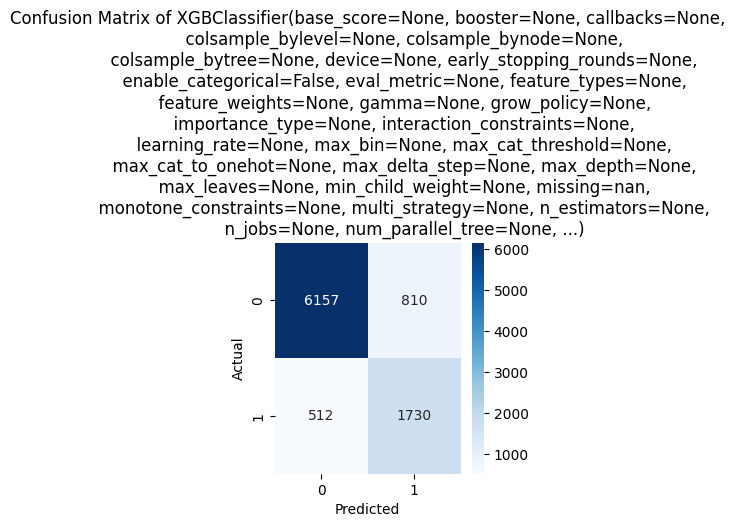

In [48]:
models=[KNeighborsClassifier(),SVC(),DecisionTreeClassifier(),GaussianNB(),RandomForestClassifier(),GradientBoostingClassifier(),XGBClassifier()]
for model in models:
    model.fit(x_over_s,y_over_s)
    y_pred=model.predict(x_test)
    print(model,"\n--------")
    print(classification_report(y_test,y_pred))
    print(accuracy_score(y_test,y_pred)*100)
    plt.figure(figsize=(3,3))
    sns.heatmap(confusion_matrix(y_test,y_pred),fmt="d",cmap="Blues",annot=True)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix of {model}")
    plt.show()

Hyper Parameter Tuning

In [ ]:
# grid search Cross Validation
from sklearn.model_selection import GridSearchCV()
parameters={
                'n_estimators' : [50, 100, 200, 300, 400, 500],
                'learning_rate' : [0.001, 0.01, 0.1, 1, 10, 100],
                'max_depth' : range(3, 8)
            }
grid=GridSearchCV(GradientBoostingClassifier(), parameters, cv=5)

In [ ]:
# randomised search CV
from sklearn.model_selection import RandomizedSearchCV
parameters={
                'n_estimators' : [50, 100, 200, 300, 400, 500],
                'learning_rate' : [0.001, 0.01, 0.1, 1, 10, 100],
                'max_depth' : range(3, 8)
            }
grid=RandomizedSearchCV(GradientBoostingClassifier(), parameters, cv=5, n_iter=5)
grid.fit(x_under, y_under)

is_classifier


c:\Users\rijok\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


TypeError: Cannot clone object. You should provide an instance of scikit-learn estimator instead of a class.

In [ ]:
# randomised search CV
from sklearn.model_selection import RandomizedSearchCV
parameters={
                'n_neighbours' : range(3, 30, 2),
                'weights' : ['uniform', 'distance'],
            }
obj1=RandomizedSearchCV(KNeighborsClassifier(), parameters, cv=5, n_iter=5)
obj1.fit(x_under, y_under)

ValueError: Invalid parameter 'weights' for estimator RandomForestClassifier(). Valid parameters are: ['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'].

In [61]:
# randomised search CV
from sklearn.model_selection import RandomizedSearchCV

parameters={
                'n_estimators' : [50, 100, 200, 300, 400, 500],
                'criterion' : ['gini', 'entropy'],
                'max_depth' : range(3, 8)
            }
#  random forest params :
#  n_estimators: Int = 100, *,
#  criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
#  max_depth: Int | None = None,
#  min_samples_split: float = 2,
#  min_samples_leaf: float = 1,
#  min_weight_fraction_leaf: Float = 0,
#  max_features: float | Literal['sqrt', 'log2'] = "sqrt",
#  max_leaf_nodes: Int | None = None,
#  min_impurity_decrease: Float = 0,
#  bootstrap: bool = True,
#  oob_score: bool = False,
#  n_jobs: Int | None = None,
#  random_state: Int | RandomState | None = None,
#  verbose: Int = 0,
#  warm_start: bool = False,
#  class_weight: Mapping | Sequence[Mapping] | Literal['balanced', 'balanced_subsample'] | None = None,
#  ccp_alpha: float = 0,
#  max_samples: float | None = None
obj1=RandomizedSearchCV(RandomForestClassifier(), parameters, cv=5, n_iter=5)
obj1.fit(x_under, y_under)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(3, 8),
                                        'n_estimators': [50, 100, 200, 300, 400,
                                                         500]})

In [62]:
obj1.best_score_

np.float64(0.7828203928405839)

In [63]:
obj1.best_params_

{'n_estimators': 400, 'max_depth': 7, 'criterion': 'entropy'}

In [65]:
pd.DataFrame(obj1.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.271285,0.216922,0.097822,0.005098,400,7,entropy,"{'n_estimators': 400, 'max_depth': 7, 'criteri...",0.762092,0.793723,0.792743,0.775744,0.789801,0.782820,0.012213,1
1,1.724443,0.019783,0.063835,0.008774,300,5,gini,"{'n_estimators': 300, 'max_depth': 5, 'criteri...",0.755882,0.793723,0.788493,0.774109,0.787185,0.779879,0.013626,2
2,1.400750,0.071069,0.050590,0.007748,300,3,gini,"{'n_estimators': 300, 'max_depth': 3, 'criteri...",0.752614,0.794704,0.783589,0.766590,0.785551,0.776610,0.015048,5
3,1.809010,0.050557,0.062918,0.001810,300,5,entropy,"{'n_estimators': 300, 'max_depth': 5, 'criteri...",0.753922,0.791435,0.788820,0.770186,0.785551,0.777983,0.014110,4
4,0.609204,0.011109,0.030707,0.016998,100,5,entropy,"{'n_estimators': 100, 'max_depth': 5, 'criteri...",0.761765,0.789474,0.786532,0.770840,0.786858,0.779094,0.010879,3


In [64]:
final=obj1.best_estimator_